Import necessary library

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
df = pd.read_csv("../data/processed/02_basic_features.csv")


In [4]:
df.head(10)

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len,month,hour,is_weekend,word_count,num_caps,num_digits,num_urls
0,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,4282,24,12,0,0,1572,0,315,0
1,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,38,28,12,0,0,8,0,1,0
2,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,1171,10,12,0,0,344,0,68,0
3,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1124,25,12,0,0,318,0,55,0
4,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,534,24,12,0,0,119,0,19,0
5,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14,0,411,21,12,0,0,90,0,76,0
6,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1375,19,12,0,0,340,0,146,0
7,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14,0,1616,10,12,0,0,328,0,45,0
8,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14,0,3039,22,12,0,0,640,0,28,0
9,entex transistion,the purpose of the email is to recap the kicko...,ham,1999-12-14,0,1734,17,12,0,0,329,0,14,0


In [5]:
df.columns

Index(['Subject', 'Message', 'Spam/Ham', 'Date', 'label', 'message_len',
       'subject_len', 'month', 'hour', 'is_weekend', 'word_count', 'num_caps',
       'num_digits', 'num_urls'],
      dtype='str')

The statistics show missing data for the entire column

In [6]:
df.isna().sum().sort_values(ascending=False)

Subject        0
Message        0
Spam/Ham       0
Date           0
label          0
message_len    0
subject_len    0
month          0
hour           0
is_weekend     0
word_count     0
num_caps       0
num_digits     0
num_urls       0
dtype: int64

No missing in dataframe

Find the empty/white-space 

In [7]:
subj_blank = df['Subject'].isna() | (df["Subject"].str.strip() == "")
date_blank = df["Date"].isna() | (df["Date"].str.strip() == "")
df[subj_blank | date_blank]

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len,month,hour,is_weekend,word_count,num_caps,num_digits,num_urls


In [8]:
date_parsed = pd.to_datetime(df["Date"], errors="coerce")  
bad_dates = df[date_parsed.isna()] 

In [9]:
dup_mask = df.duplicated(["Subject", "Message"], keep=False)  
dup_count = dup_mask.sum()                                                                                                                                                                                        
df_duplicates = df[dup_mask]   

In [10]:
print(df.shape)
print(df_duplicates.shape)

(33664, 14)
(18369, 14)


In [11]:
dup_stats = (
  df.groupby(["Subject","Message"])
   .agg(
     count=("label", "size"),
     label_variants=("label","nunique"),
     spamham_variants=("Spam/Ham","nunique")
   )
   .reset_index()
)

In [12]:
print(dup_stats[dup_stats["spamham_variants"] > 1].shape)
print(dup_stats.shape)

(6, 5)
(15861, 5)


### Xử lý dữ liệu trùng lặp
Chúng ta sẽ loại bỏ các dòng bị trùng hoàn toàn (cả `Subject` và `Message`), đồng thời loại bỏ các dòng bị mâu thuẫn nhãn (cùng nội dung nhưng vừa là Spam vừa là Ham) để tránh rò rỉ và nhiễu dữ liệu.

In [13]:
# 1. Loại bỏ các dòng mâu thuẫn nhãn (Contradictory labels)
contradictory = dup_stats[dup_stats['spamham_variants'] > 1]
# Lọc bỏ những dòng có Subject và Message nằm trong list mâu thuẫn
df_clean = df[~df.set_index(['Subject', 'Message']).index.isin(contradictory.set_index(['Subject', 'Message']).index)].copy()

# 2. Loại bỏ các dòng trùng lặp 100%, chỉ giữ lại bản ghi đầu tiên
df_clean = df_clean.drop_duplicates(subset=['Subject', 'Message'], keep='first')

print(f"Kích thước ban đầu: {df.shape}")
print(f"Kích thước sau khi xoá trùng lặp: {df_clean.shape}")
print(f"Số lượng dòng bị loại bỏ: {df.shape[0] - df_clean.shape[0]}")

Kích thước ban đầu: (33664, 14)
Kích thước sau khi xoá trùng lặp: (15855, 14)
Số lượng dòng bị loại bỏ: 17809


### Xử lý Missing/Rác ở Subject & Date
Kiểm tra lại null và các chuỗi rỗng.

In [14]:
# Replace empty space string with np.nan and drop them
df_clean['Subject'] = df_clean['Subject'].replace(r'^\s*$', np.nan, regex=True)
df_clean['Date'] = df_clean['Date'].replace(r'^\s*$', np.nan, regex=True)

df_clean = df_clean.dropna(subset=['Subject', 'Date'])
print(f"Kích thước sau khi drop null Subject/Date: {df_clean.shape}")

Kích thước sau khi drop null Subject/Date: (15855, 14)


### Phân tích Outlier cho Độ dài tiêu đề (`subject_len`) 
Vẽ Boxplot và tiến hành cắt cụt (clipping) bằng phương pháp dải phân vị IQR.

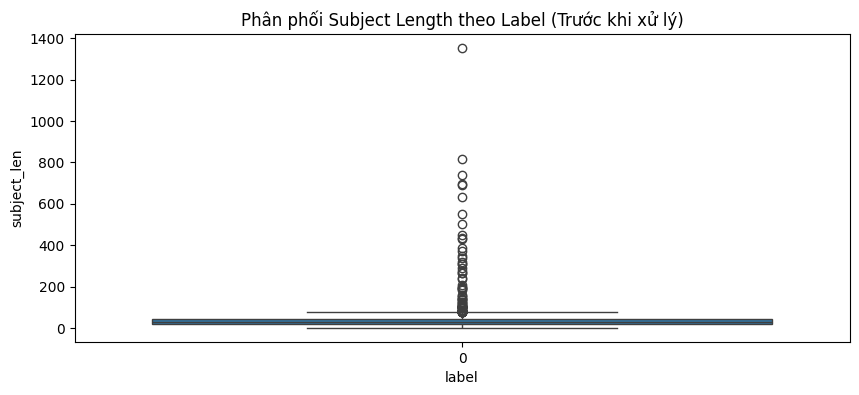

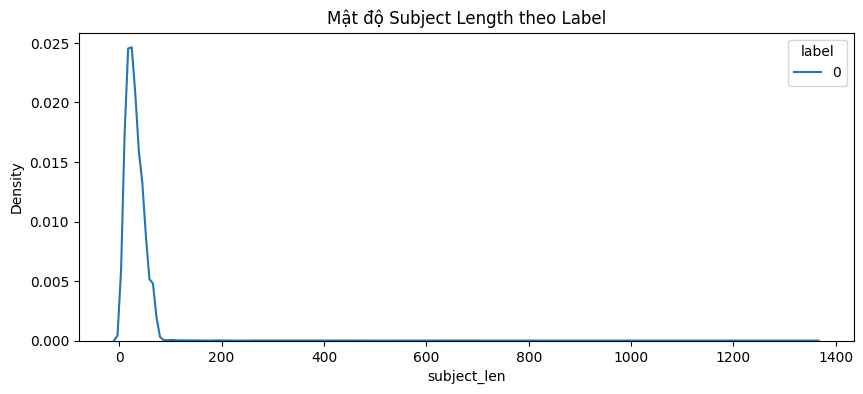

In [15]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='label', y='subject_len', data=df_clean)
plt.title('Phân phối Subject Length theo Label (Trước khi xử lý)')
plt.show()

plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_clean, x='subject_len', hue='label', common_norm=False)
plt.title('Mật độ Subject Length theo Label')
plt.show()

Giới hạn trên cho subject_len: 75.5


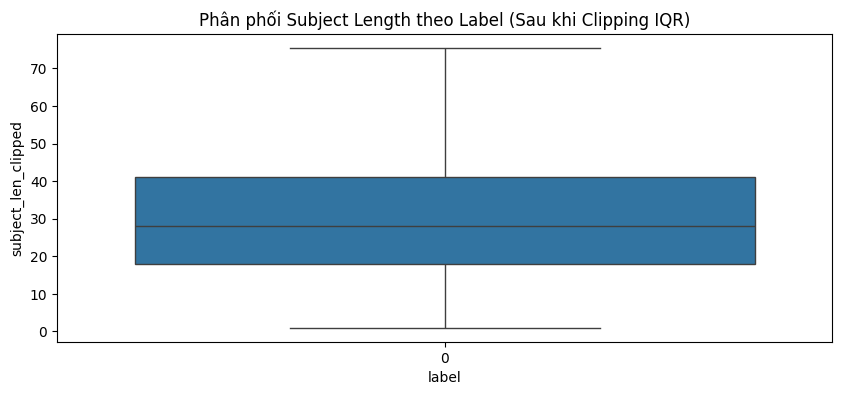

In [16]:
# Cắt outlier bằng IQR
Q1 = df_clean['subject_len'].quantile(0.25)
Q3 = df_clean['subject_len'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Giới hạn trên cho subject_len: {upper_bound}")

# Thay vì bỏ luôn dòng, ta clip giới hạn trên để không làm mất dữ liệu text
df_clean['subject_len_clipped'] = df_clean['subject_len'].clip(upper=upper_bound)

plt.figure(figsize=(10, 4))
sns.boxplot(x='label', y='subject_len_clipped', data=df_clean)
plt.title('Phân phối Subject Length theo Label (Sau khi Clipping IQR)')
plt.show()

### Phân tích theo lát cắt thời gian (Tháng/Quý)
Phát hiện xu hướng theo mùa vụ (seasonality) và sự xê dịch email rác (drift).

In [17]:
df_clean['Date_parsed'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_valid_dates = df_clean.dropna(subset=['Date_parsed']).copy()

df_valid_dates['year_month'] = df_valid_dates['Date_parsed'].dt.to_period('M')
df_valid_dates['quarter'] = df_valid_dates['Date_parsed'].dt.to_period('Q')
df_valid_dates['day_of_week'] = df_valid_dates['Date_parsed'].dt.day_name()

# Sắp xếp theo trình tự thời gian
df_valid_dates = df_valid_dates.sort_values('Date_parsed')


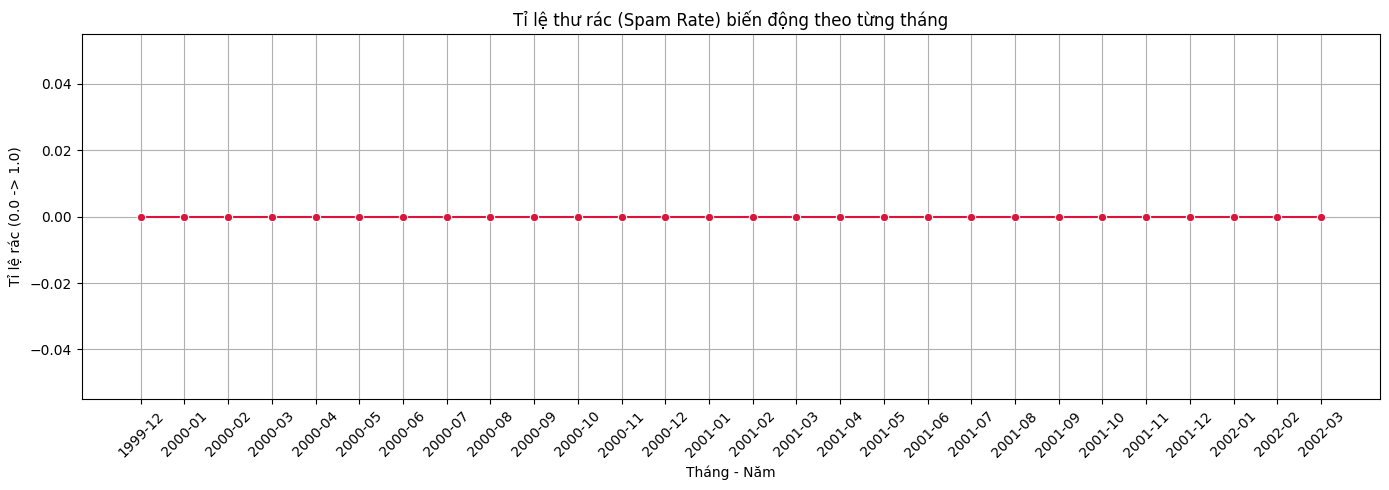

In [18]:
# Tỉ lệ mác Spam theo từng tháng
monthly_counts = df_valid_dates.groupby('year_month')['label'].agg(['count', 'mean']).reset_index()
monthly_counts['year_month_str'] = monthly_counts['year_month'].astype(str)

# Chỉ lấy những tháng có lượng mẫu đủ lớn (vd: > 50) để biểu đồ không nhiễu
filtered_monthly = monthly_counts[monthly_counts['count'] > 50]

plt.figure(figsize=(14, 5))
sns.lineplot(data=filtered_monthly, x='year_month_str', y='mean', marker='o', color='crimson')
plt.xticks(rotation=45)
plt.title('Tỉ lệ thư rác (Spam Rate) biến động theo từng tháng')
plt.ylabel('Tỉ lệ rác (0.0 -> 1.0)')
plt.xlabel('Tháng - Năm')
plt.grid(True)
plt.tight_layout()
plt.show()

Quá trình kết xuất lại tập tin `03_data_quality_and_time_trends.csv` sau khi đã clean.

In [19]:
df.to_csv("../data/processed/03_quality_trends.csv", index=False)
